In [1]:
# Import necessary libraries
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import tqdm
import seaborn as sns

In [2]:
# Load the MNIST dataset
mnist = fetch_openml('mnist_784')
X, y = mnist['data'], mnist['target']

c:\Users\jaide\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
X.shape, y.shape

((70000, 784), (70000,))

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=10000, random_state=42)

In [5]:
import torch
import torch.nn as nn

In [6]:
model = nn.Sequential(
    nn.Linear(784, 30),
    nn.ReLU(),
    nn.Linear(30, 20),
    nn.ReLU(),
    nn.Linear(20, 10),
    nn.Sigmoid()
)

In [7]:
X_train = np.array(X_train)
y_train = np.array(y_train)
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(np.array(list(map(int, list(y_train))))).long()

In [8]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for n in tqdm.tqdm(range(1000)):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

100%|██████████| 1000/1000 [01:13<00:00, 13.64it/s]


In [9]:
X_test = np.array(X_test)
y_test = np.array(y_test)
X_test = torch.from_numpy(X_test).float()


In [10]:
y_test_pred = model(X_test)
y_test_pred = torch.argmax(y_test_pred, dim=1)
y_test_pred

tensor([8, 4, 8,  ..., 3, 8, 3])

In [11]:
y_test = torch.from_numpy(np.array(list(map(int, list(y_test)))))
y_test

tensor([8, 4, 8,  ..., 3, 8, 3], dtype=torch.int32)

In [12]:
# Convert y_test_pred to objects
y_test_pred = np.array(y_test_pred).astype(int)
y_test_pred

array([8, 4, 8, ..., 3, 8, 3])

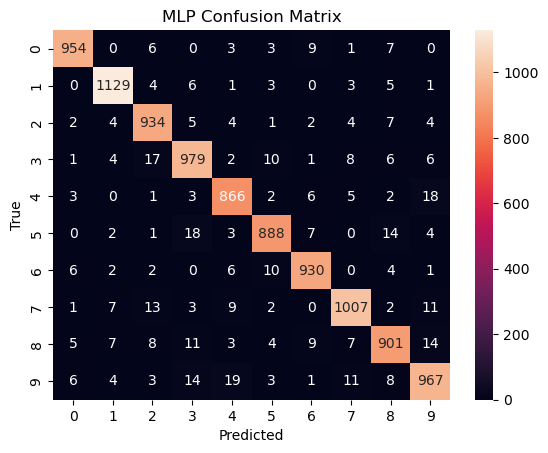

              precision    recall  f1-score   support

           0       0.98      0.97      0.97       983
           1       0.97      0.98      0.98      1152
           2       0.94      0.97      0.96       967
           3       0.94      0.95      0.94      1034
           4       0.95      0.96      0.95       906
           5       0.96      0.95      0.95       937
           6       0.96      0.97      0.97       961
           7       0.96      0.95      0.96      1055
           8       0.94      0.93      0.94       969
           9       0.94      0.93      0.94      1036

    accuracy                           0.96     10000
   macro avg       0.96      0.96      0.96     10000
weighted avg       0.96      0.96      0.96     10000



In [13]:

cm = confusion_matrix(y_test, y_test_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP Confusion Matrix')
plt.show()

print(classification_report(y_test, y_test_pred))

TSNE Visualisations

In [14]:
model

Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=10, bias=True)
  (5): Sigmoid()
)

In [15]:
model.parameters

<bound method Module.parameters of Sequential(
  (0): Linear(in_features=784, out_features=30, bias=True)
  (1): ReLU()
  (2): Linear(in_features=30, out_features=20, bias=True)
  (3): ReLU()
  (4): Linear(in_features=20, out_features=10, bias=True)
  (5): Sigmoid()
)>

In [16]:
layer1theta = list(model.parameters())[0]
layer1theta.shape

torch.Size([30, 784])

In [17]:
layer1b = list(model.parameters())[1]
layer1b.shape

torch.Size([30])

In [18]:
layer2theta = list(model.parameters())[2]
layer2theta.shape

torch.Size([20, 30])

In [19]:
layer2b = list(model.parameters())[3]
layer2b.shape

torch.Size([20])

In [20]:
y_20neurons = (X_test.mm(layer1theta.T) + layer1b).mm(layer2theta.T) + layer2b

In [21]:
y_20neurons.shape

torch.Size([10000, 20])

(10000, 2)


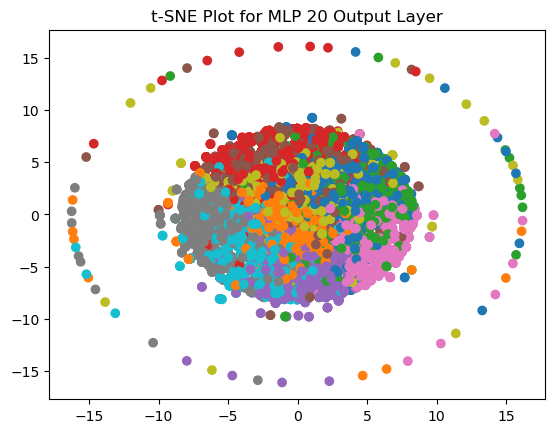

In [22]:
# Plot t-SNE for the output from the layer containing 20 neurons
tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=42)
y_20neurons = tsne.fit_transform(y_20neurons.detach())
print(y_20neurons.shape)
plt.scatter(y_20neurons[:, 0], y_20neurons[:, 1], c=y_test, cmap='tab10')
plt.title('t-SNE Plot for MLP 20 Output Layer')
plt.show()

In [23]:
import plotly.express as px
px.scatter(x=y_20neurons[:, 0], y=y_20neurons[:, 1], color=np.array(y_test).astype(str))


In [24]:
# Repeating the same procedure for an untrained model
model1 = nn.Sequential(
    nn.Linear(784, 30),
    nn.ReLU(),
    nn.Linear(30, 20),
    nn.ReLU(),
    nn.Linear(20, 10),
    nn.Sigmoid()
)

In [25]:
layer1theta = list(model1.parameters())[0]
layer1b = list(model1.parameters())[1]
layer2theta = list(model1.parameters())[2]
layer2b = list(model1.parameters())[3]

y20_untrained = (X_test.mm(layer1theta.T) + layer1b).mm(layer2theta.T) + layer2b


(10000, 2)


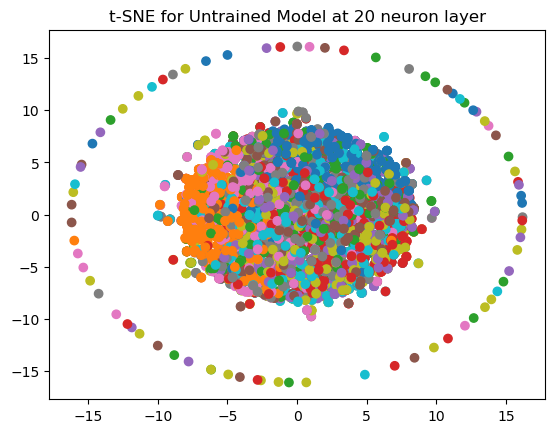

In [26]:
tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=42)
y20_untrained = tsne.fit_transform(y20_untrained.detach())
print(y20_untrained.shape)
plt.scatter(y20_untrained[:, 0], y20_untrained[:, 1], c=y_test, cmap='tab10')
plt.title('t-SNE for Untrained Model at 20 neuron layer')
plt.show()

In [27]:
px.scatter(x=y20_untrained[:, 0], y=y20_untrained[:, 1], color=np.array(y_test).astype(str))

In [28]:

# Load Fashion-MNIST dataset
fashion_mnist = fetch_openml(name='Fashion-MNIST')

X = fashion_mnist.data
y = fashion_mnist.target

c:\Users\jaide\anaconda3\Lib\site-packages\sklearn\datasets\_openml.py:968: FutureWarning:

The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.



In [29]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
for n in tqdm.tqdm(range(1000)):
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

100%|██████████| 1000/1000 [02:46<00:00,  5.99it/s]


In [30]:
layer1theta = list(model.parameters())[0]
layer1b = list(model.parameters())[1]
layer2theta = list(model.parameters())[2]
layer2b = list(model.parameters())[3]


In [31]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X, y, test_size=10000, random_state=42)

X1_test = np.array(X1_test)
X1_test = torch.from_numpy(X1_test).float()
y1_test = np.array(y1_test)
y1_test = torch.from_numpy(np.array(list(map(int, list(y1_test)))))


In [32]:
y20_pred = (X1_test.mm(layer1theta.T) + layer1b).mm(layer2theta.T) + layer2b


In [33]:
tsne = TSNE(perplexity=1, n_components=2, n_iter=250, random_state=42)
y20_pred = tsne.fit_transform(y20_pred.detach())
print(y20_pred.shape)

(10000, 2)


In [34]:
y20_pred

array([[ 3.309872  , -0.48606908],
       [-6.0894465 , -2.9527595 ],
       [ 2.8947744 , -5.453857  ],
       ...,
       [ 1.4619874 ,  0.50077724],
       [ 3.3132918 ,  2.1907752 ],
       [ 2.5072305 ,  4.1358795 ]], dtype=float32)

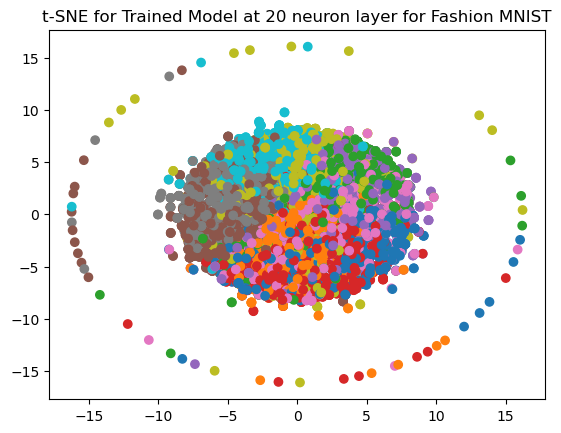

In [35]:
plt.scatter(y20_pred[:, 0], y20_pred[:, 1], c=y1_test, cmap='tab10')
plt.title('t-SNE for Trained Model at 20 neuron layer for Fashion MNIST')
plt.show()

In [36]:
px.scatter(x=y20_pred[:, 0], y=y20_pred[:, 1], color=np.array(y1_test).astype(str))

Prediction on Fashion MNIST

In [39]:
y1_pred = model(X1_test)
y1_pred = torch.argmax(y1_pred, dim=1)

In [40]:
y1_pred

tensor([3, 4, 8,  ..., 8, 8, 0])

In [42]:
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

           0       0.01      0.01      0.01       995
           1       0.00      0.00      0.00      1001
           2       0.00      0.00      0.00       997
           3       0.09      0.02      0.03      1042
           4       0.00      0.00      0.00       948
           5       0.61      0.05      0.09      1022
           6       0.11      0.05      0.07      1032
           7       0.04      0.00      0.00       982
           8       0.05      0.24      0.08       955
           9       0.01      0.00      0.00      1026

    accuracy                           0.04     10000
   macro avg       0.09      0.04      0.03     10000
weighted avg       0.09      0.04      0.03     10000



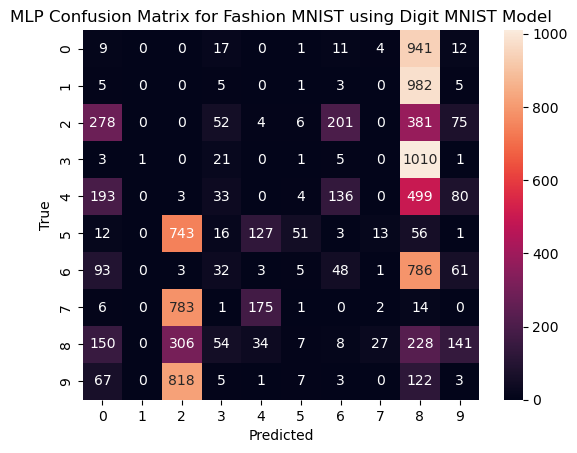

In [44]:
cm = confusion_matrix(y1_test, y1_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('MLP Confusion Matrix for Fashion MNIST using Digit MNIST Model')
plt.show()

## Observations for T-SNE and prediction results
* We can observe from the embedding visualisation for the model trained on the MNIST dataset has a very well segregated class wise separation even in the two dimensional space. This is because the model is trained on the train part of the MNIST dataset which captures the trends for the test part of the MNIST dataset, whcih leads to a well segregated embedding in 20 dim.

* We can observe from the embedding visualisation of the untrained model that the 2 dimensional representation still captures some trends of the segregation but it is quite worse in terms of segreagation compared to the trained model.
* We can observe from the embedding of Fashion MNIST that the dataset embedding minutely captures the trend but it is still worse segregated as the model is not specialised for the classification of fashion dataset. It is for the digits dataset.
* From the prediction of the model trained on MNIST digits dataset on the Fashion MNIST dataset, we can see that the results of this prediction are very poor with an accuracy of just 4%.